# Etapa 05 — ¿Qué respuestas merecen un estudio sectorial más profundo?

Consulta el dossier. Predice, calcula, explica y juzga el alcance antes de registrar tu decisión.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

In [2]:
from sa_mise import sector
CASO='ejemplo_docente'
# Usa el mismo identificador de tu equipo en las ocho etapas.

## 1. Respuestas físicas sobre una misma base
Construimos la matriz alternativa–escenario. Antes de ordenar, mira faltante, ahorro y estado final. El programa de demanda es una reducción supuesta, no demanda insatisfecha.

,escenario,alternativa,faltante_MWh,ahorro_MWh,stock_final_MWh_eq,costo_parcial_COP
0,Referencia,Base,0.000000,0.0,193687.513879,3.842136e+11
1,Referencia,Solar adicional 20 MW,0.000000,0.0,193687.513879,4.254520e+11
2,Referencia,Reducción de demanda 5%,0.000000,140352.0,193687.513879,3.470904e+11
3,Referencia,Reserva operativa 60000 MWh,0.000000,0.0,193687.513879,3.927936e+11
4,Referencia,Solar + reducción de demanda,0.000000,140352.0,193687.513879,3.883288e+11
5,Aportes al 45%,Base,294271.475019,0.0,0.000000,4.931866e+11
6,Aportes al 45%,Solar adicional 20 MW,257932.475019,0.0,0.000000,5.471436e+11
7,Aportes al 45%,Reducción de demanda 5%,222892.475019,140352.0,0.000000,4.810460e+11
8,Aportes al 45%,Reserva operativa 60000 MWh,335254.475019,0.0,60000.000000,4.980425e+11
9,Aportes al 45%,Solar + reducción de demanda,187852.475019,140352.0,0.000000,5.345484e+11


alternativa,Base,Reducción de demanda 5%,Reserva operativa 60000 MWh,Solar + reducción de demanda,Solar adicional 20 MW
escenario,,,,,
Aportes al 45%,106419.0,35040.0,147402.0,0.0,70080.0
Mismo aporte desplazado,0.0,0.0,0.0,0.0,0.0
Referencia,0.0,0.0,0.0,0.0,0.0
Sequía y térmica al 55%,199728.0,64416.0,259728.0,0.0,129552.0


alternativa
Solar + reducción de demanda         0.0
Reducción de demanda 5%          64416.0
Solar adicional 20 MW           129552.0
Base                            199728.0
Reserva operativa 60000 MWh     259728.0
Name: Peor arrepentimiento en faltante MWh, dtype: float64

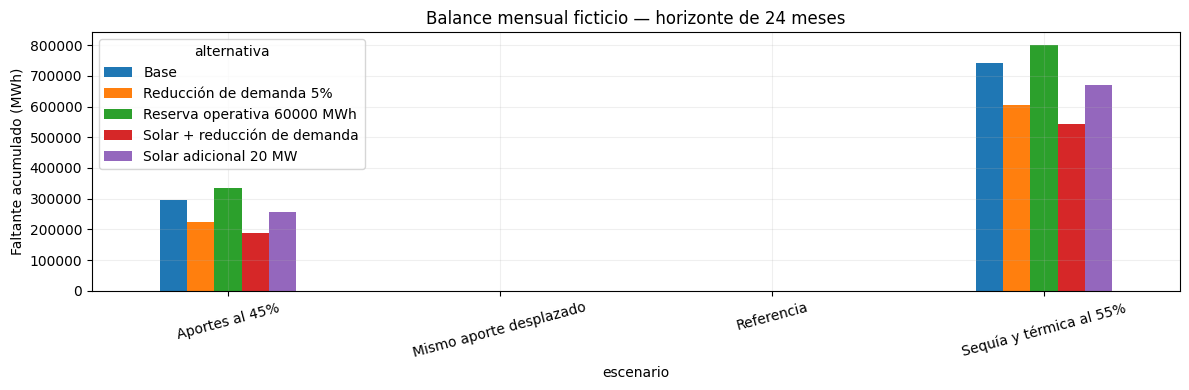

In [3]:
respuestas=sector.comparar_respuestas()
display(respuestas[['escenario','alternativa','faltante_MWh','ahorro_MWh','stock_final_MWh_eq','costo_parcial_COP']])
faltantes=respuestas.pivot(index='escenario',columns='alternativa',values='faltante_MWh')
regret=faltantes.sub(faltantes.min(axis=1),axis=0)
display(regret);display(regret.max().sort_values().rename('Peor arrepentimiento en faltante MWh'))
faltantes.plot.bar(figsize=(12,4));plt.ylabel('Faltante acumulado (MWh)');plt.title('Balance mensual ficticio — horizonte de 24 meses');plt.xticks(rotation=15);plt.tight_layout();plt.show()

El criterio menor faltante no incorpora todos los costos ni efectos distributivos. Observa si hay empates y qué ocurre en el estrés combinado. El stock final importa: gastar agua hoy puede mejorar una cifra del horizonte y dejar una condición peor después. La tabla de costos es parcial y el horizonte no representa ciclo de vida.

**Lectura del resultado ejecutado:** la reserva fija presenta más faltante en los escenarios secos de este ejercicio. La regla retiene un piso de agua incluso cuando queda demanda sin atender; no representa una política óptima de conservación. El resultado invita a revisar cuándo se libera la reserva y cómo se valora el estado terminal, en vez de concluir que conservar agua carece de valor. La combinación solar–reducción mejora la métrica física, pero su costo y viabilidad requieren un juicio separado. Las barras nulas en escenarios de referencia no certifican suficiencia horaria.

## 2. La perspectiva empresarial conserva su propio criterio
La planta ficticia del anexo usa costos y precios supuestos. El VPN no se obtiene de las trayectorias sectoriales anteriores. Comparamos mercante, PPA y no construir sin atribuir el resultado a política nacional.

In [4]:
caja,vpn=modelos.caja_proyecto();display(caja.head())
valores,regret_financiero,ranking=modelos.escenarios_negocio();display(valores);display(ranking)
print('VPN docente de referencia [miles de millones COP]:',vpn/1e9)

VPN docente de referencia [miles de millones COP]: -3.4956055128824577


,anio,energia_MWh,ingreso_PPA_COP,ingreso_spot_COP,opex_COP,capex_COP,flujo_COP,valor_presente_COP
0,0,0.00000,0.000000e+00,0.000000e+00,0.0,6.400000e+10,-6.400000e+10,-6.400000e+10
1,1,35040.00000,5.045760e+09,3.223680e+09,900000000.0,0.000000e+00,7.369440e+09,6.699491e+09
2,2,34864.80000,5.020531e+09,3.207562e+09,900000000.0,0.000000e+00,7.328093e+09,6.056275e+09
3,3,34690.47600,4.995429e+09,3.191524e+09,900000000.0,0.000000e+00,7.286952e+09,5.474795e+09
4,4,34517.02362,4.970451e+09,3.175566e+09,900000000.0,0.000000e+00,7.246018e+09,4.949128e+09


,No construir,Solar 20 MW mercante,Solar 20 MW PPA parcial
Referencia,0.0,-5.228655,-3.495606
Precio capturado bajo,0.0,-34.112808,-15.049267
Conexión tardía,0.0,-15.428640,-13.996368
Producción baja,0.0,-28.335977,-23.136830


,min_VPN_miles_millones_COP,max_regret_miles_millones_COP,admisible_financieramente
No construir,0.000000,0.000000,True
Solar 20 MW PPA parcial,-23.136830,23.136830,False
Solar 20 MW mercante,-34.112808,34.112808,False


Una decisión empresarial de no construir puede ser admisible financieramente y no resolver una necesidad de abastecimiento. Explica esa diferencia de destinatario. Para recomendar una intervención sectorial, formula mecanismo de implementación, estudio siguiente y condición de cambio; no traslades el ranking de VPN.

## Registrar el avance del equipo
Sustituye el campo de decisión por tu razonamiento y conserva el nivel de evidencia. El identificador es el mismo durante todo el caso.

In [5]:
decision_estudiante='POR COMPLETAR'
expediente.registrar(CASO,'decision','Comparación física de '+str(len(respuestas))+' combinaciones y ventana financiera separada','descripcion' if 5 in [0,1] else 'exploracion',
 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
 decision_estudiante)

Out[5]: 
{'version': 2,
 'caso': 'ejemplo_docente',
 'etapas': {'evidencia': {'hallazgo': 'Año 2024: generación 83262.923 GWh y pico 11704.365 MW; son magnitudes diferentes',
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
   'limite': 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
   'decision_estudiante': 'POR COMPLETAR'},
  'identidad': {'hallazgo': "Asociaciones mensuales: {'meses': 264, 'correlacion_bruta': -0.3654022452929349, 'correlacion_residual': -0.5459860648178948, 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}",
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícit